In [1]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

jit_find_library(): Unable to load "/usr/lib/llvm-15/lib/libLLVM.so": /home/jonathan/miniconda3/envs/volprim/lib/python3.11/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/llvm-15/lib/libLLVM.so)!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.052795798..5.503155].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011931339..5.895548].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019491877..1.5766091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.6146151].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13119924..1.4960034].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07424388..1.6359291].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0963471..1.60

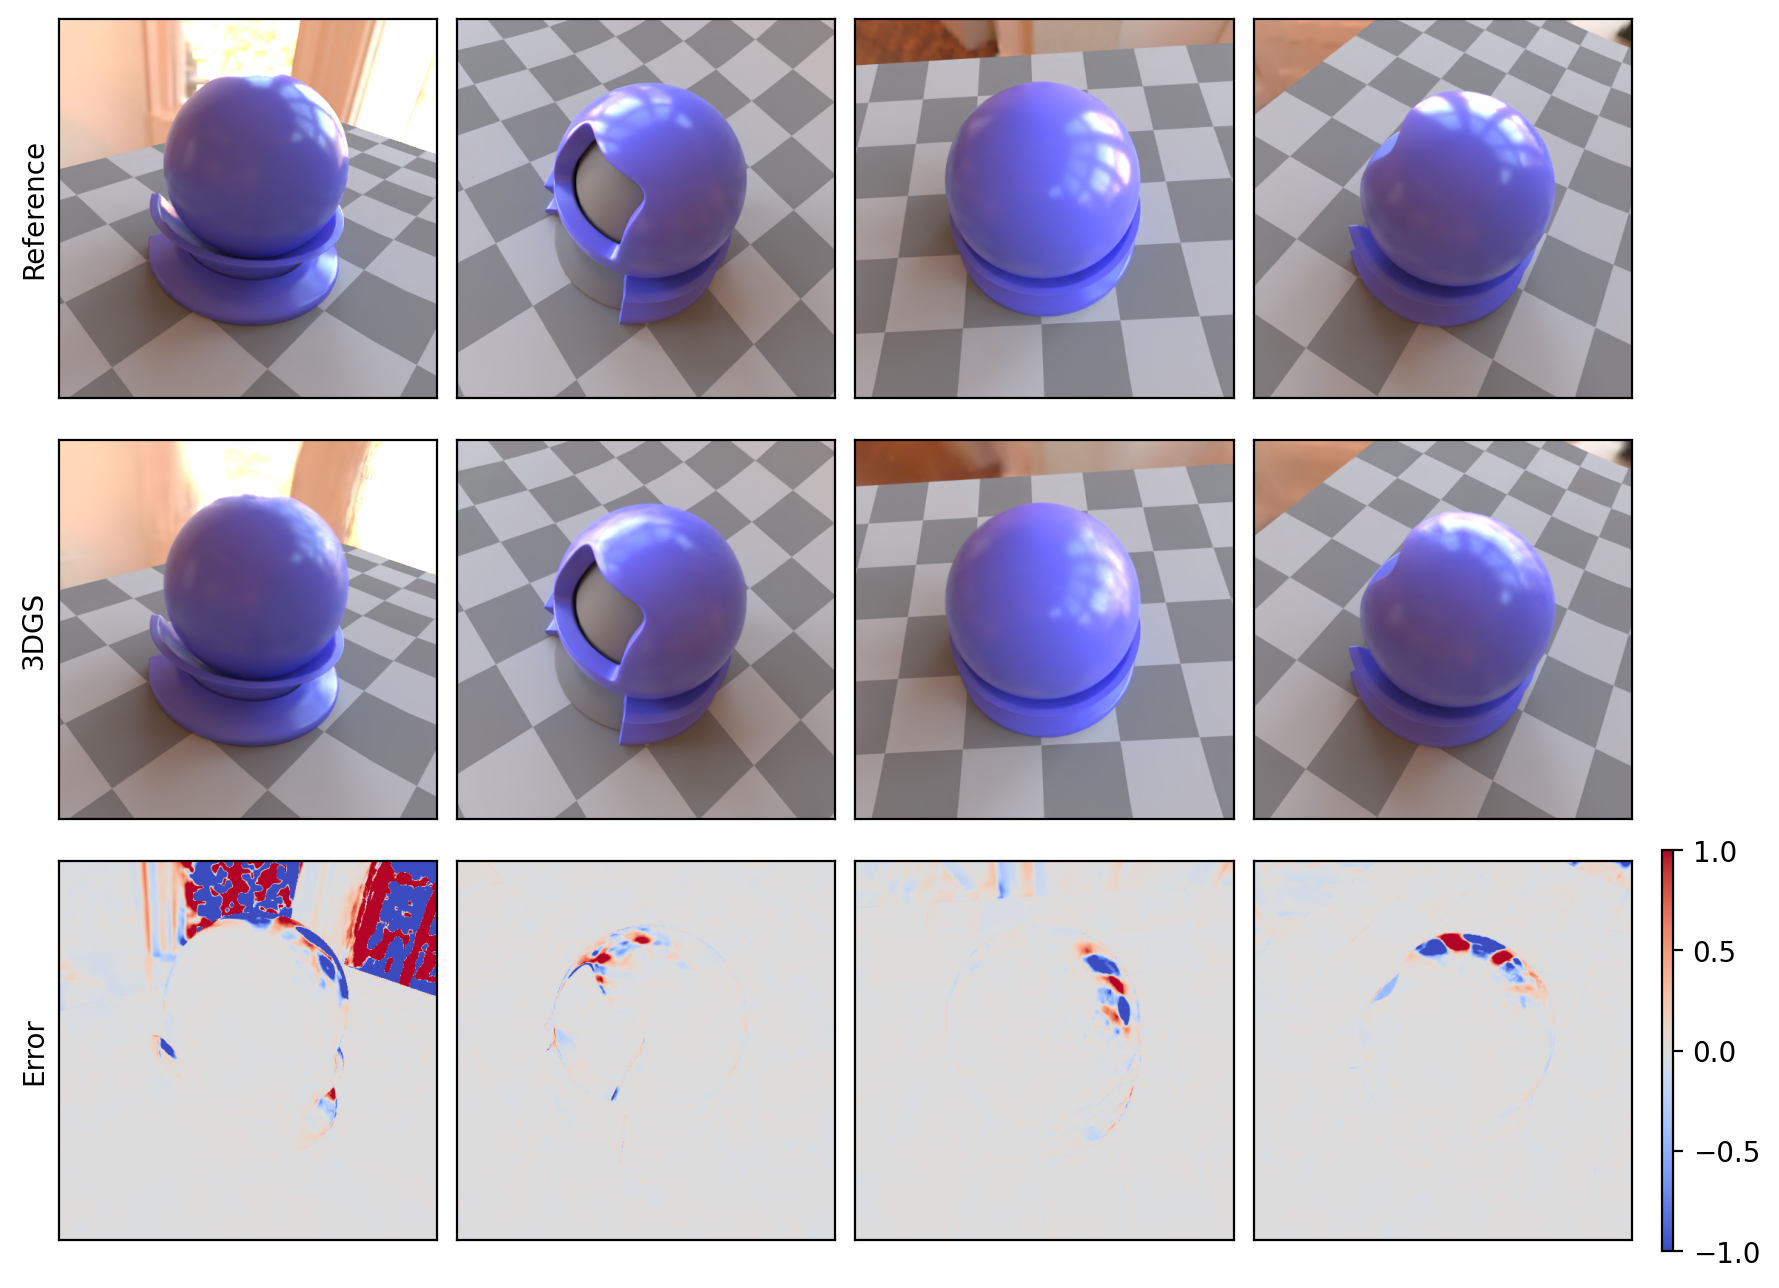

In [3]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

fp = "/home/jonathan/Documents/volprim-balance/figure_imgs/"
filenames = os.listdir(os.path.join(fp, "GS"))

filenames = [filename for idx, filename in enumerate(filenames) if idx in [3,4,5,6]]
# filenames = [filename for idx, filename in enumerate(filenames) if idx in [0,2,4]]


num_files = len(filenames)

fig = plt.figure(figsize=((num_files - 1)*3, 2.2*3), dpi=200)
grid = fig.add_gridspec(3, num_files)
grid = ImageGrid(fig, 111,
                nrows_ncols=(3,num_files),
                axes_pad=0.1,
                aspect=False,
                share_all=True,
                cbar_location="right",
                cbar_mode="edge",
                cbar_size="3%",
                cbar_pad=0.15,
                )

for idx, filename in enumerate(filenames):
    img_gs = mi.TensorXf(mi.Bitmap(os.path.join(fp, "GS", filename)).convert(mi.Bitmap.PixelFormat.RGB, mi.Struct.Type.Float32))
    img_rt = mi.TensorXf(mi.Bitmap(os.path.join(fp, "RT", filename)).convert(mi.Bitmap.PixelFormat.RGB, mi.Struct.Type.Float32))

    error = img_gs - img_rt
    error = error[:,:,0] + error[:,:,1] + error[:,:,2]
    error_range = dr.max(dr.abs(error), axis=None).numpy().item()
    # print(error_range)
    error_range = 1

    # GS image
    # ax = fig.add_subplot(grid[0, idx])
    ax = grid[4 + idx]
    ax.imshow(img_gs ** (1 / 2.2)); ax.set_xticks([]); ax.set_yticks([])
    if idx == 0:
        ax.set_ylabel("3DGS")

    # RT image
    # ax = fig.add_subplot(grid[1, idx])
    ax = grid[0 + idx]
    ax.imshow(img_rt ** (1 / 2.2)); ax.set_xticks([]); ax.set_yticks([])
    if idx == 0:
        ax.set_ylabel("Reference")

    # Error image
    # ax = fig.add_subplot(grid[2, idx])
    ax = grid[8 + idx]
    im = ax.imshow(error, vmin=-error_range, vmax=error_range, cmap='coolwarm'); ax.set_xticks([]); ax.set_yticks([])
    if idx == 0:
        ax.set_ylabel("Error")


grid.cbar_axes[0].remove()
grid.cbar_axes[1].remove()
ax.cax.colorbar(im)
plt.tight_layout()
plt.savefig("Exp2-4_specular.png")
